## Кіріспе

**Компьютерлік көру (Computer Vision)** — компьютерлердің сандық кескіндерден мағыналы ақпарат алуын зерттейтін жасанды интеллект саласы. Адам миы секундтар ішінде суреттен ондаған нысанды анықтайды; қазіргі терең оқыту модельдері осы міндетті одан да жылдам орындайды.

Бұл дəптер Computer Vision-дің төрт негізгі тапсырмасын бір жерде қамтиды. Əр тапсырма минималды, бірақ жұмыс жасайтын түрде іске асырылады. Кейін əр тапсырма өзінің бөлек зертханасында тереңірек зерттеледі.

| Тапсырма | Сұрақ | Шығыс |
|---|---|---|
| **Классификация** | Бұл не? | Тап + ықтималдық |
| **Детекция** | Қайда жəне не? | Bounding box + тап |
| **Сегментация** | Əр пиксель қай таптікі? | Пиксель маскасы |
| **Генерация** | Жаңа сурет жаса | Синтетикалық кескін |

## Оқу Мақсаттары

- CV-дің төрт негізгі тапсырмасын жəне олардың айырмасын түсіндіре аласыз
- CNN классификаторын үйретіп, GradCAM арқылы шешімді визуализациялай аласыз
- YOLO-стиль detekция принципін жəне Anchor box тұжырымдамасын сипаттай аласыз
- U-Net архитектурасын нөлден жасай аласыз
- DCGAN-ды үйретіп, синтетикалық кескін генерациялай аласыз
- Əр тапсырманың негізгі метрикасын (Top-1 Accuracy, mAP, IoU, FID) түсінесіз


## 1-бөлім: Кітапханаларды Импорттау

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input, decode_predictions
)

print("TensorFlow нұсқасы:", tf.__version__)
print("GPU бар ма:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow нұсқасы: 2.20.0
GPU бар ма: True


In [4]:
tf.random.set_seed(42)
np.random.seed(42)
print("Seed бекітілді.")


Seed бекітілді.


## 2-бөлім: CIFAR-10 Деректерін Жүктеу

CIFAR-10 — 10 санатты 32×32 пиксельді 60 000 түрлі-түсті суреттер жинағы. Барлық CV тапсырмалары осы жинақта демонстрацияланады.

In [5]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

CLASS_NAMES = ['ұшақ','автомобиль','құс','мысық','бұғы',
               'ит','бақа','ат','кеме','жүк машинасы']

x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

y_train_flat = y_train.flatten()
y_test_flat  = y_test.flatten()

print("Үйрету:", x_train.shape, "Тест:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1584s 9us/step
Үйрету: (50000, 32, 32, 3) Тест: (10000, 32, 32, 3)


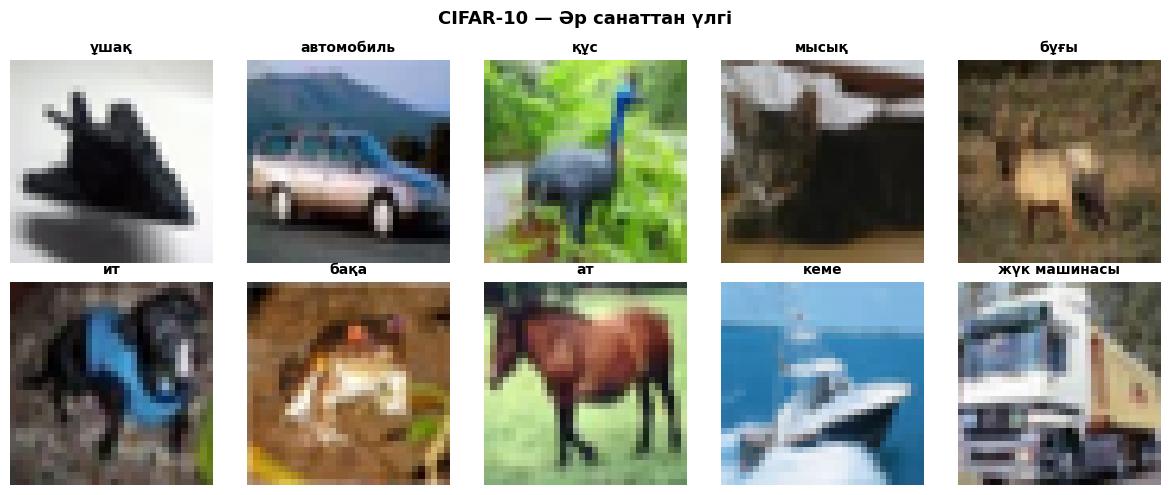

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR-10 — Əр санаттан үлгі', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    idx = np.where(y_train_flat == i)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(CLASS_NAMES[i], fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()


## 3-бөлім: Тапсырма 1 — Кескін Классификациясы

Классификация — CV-дің ең негізгі тапсырмасы. CNN суреттен иерархиялық ерекшеліктерді (жиектер → текстуралар → пішіндер → объектілер) автоматты анықтайды.

In [7]:
clf_model = keras.Sequential([
    layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(10, activation='softmax')
], name='CNN_Classifier')

clf_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
clf_model.summary()


Model: "CNN_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,922 (370.79 KB)

 Trainable params: 94,730 (370.04 KB)

 Non-trainable params: 192 (768.00 B)

In [8]:
print("CNN классификатор үйретілуде (10 дəуір)...")
history_clf = clf_model.fit(
    x_train_norm, y_train_flat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)
_, test_acc = clf_model.evaluate(x_test_norm, y_test_flat, verbose=0)
print(f"Тест дəлдігі: {test_acc:.4f}")

CNN классификатор үйретілуде (10 дəуір)...
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.4859 - loss: 1.4311 - val_accuracy: 0.1014 - val_loss: 3.4019
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6121 - loss: 1.1006 - val_accuracy: 0.5938 - val_loss: 1.1291
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6621 - loss: 0.9636 - val_accuracy: 0.5940 - val_loss: 1.1151
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6947 - loss: 0.8739 - val_accuracy: 0.6292 - val_loss: 1.0388
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7164 - loss: 0.8082 - val_accuracy: 0.6378 - val_loss: 1.0243
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7377 - loss: 0.7531 - val_accuracy: 0.6444 - val_loss: 1.0100
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7546 - loss: 0.7073 - val_accuracy: 0.6278 - val_loss: 1.0667
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accur

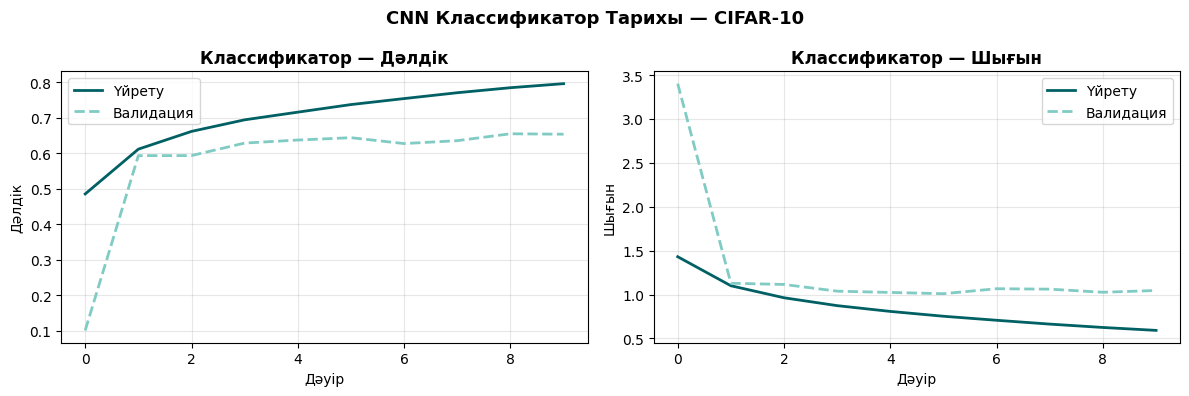

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_clf.history['accuracy'], label='Үйрету', linewidth=2, color='#006064')
ax1.plot(history_clf.history['val_accuracy'], label='Валидация', linewidth=2, color='#80cbc4', linestyle='--')
ax1.set_title('Классификатор — Дəлдік', fontsize=12, fontweight='bold')
ax1.set_xlabel('Дəуір')
ax1.set_ylabel('Дəлдік')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_clf.history['loss'], label='Үйрету', linewidth=2, color='#006064')
ax2.plot(history_clf.history['val_loss'], label='Валидация', linewidth=2, color='#80cbc4', linestyle='--')
ax2.set_title('Классификатор — Шығын', fontsize=12, fontweight='bold')
ax2.set_xlabel('Дəуір')
ax2.set_ylabel('Шығын')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('CNN Классификатор Тарихы — CIFAR-10', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


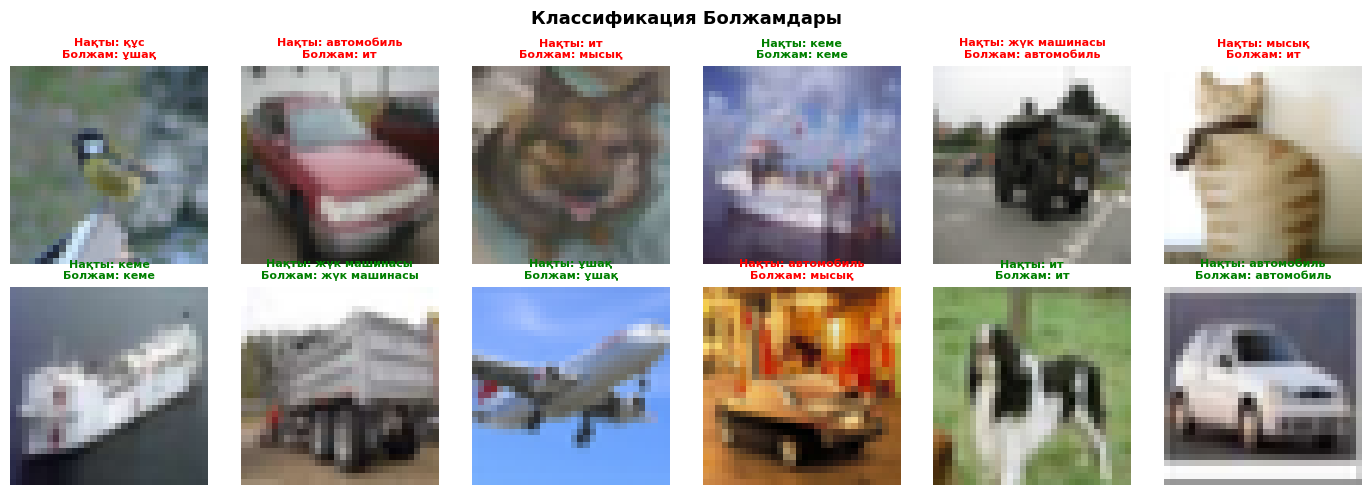

In [10]:
sample_idx = np.random.choice(len(x_test), 12, replace=False)
x_sample = x_test_norm[sample_idx]
y_sample = y_test_flat[sample_idx]

preds = clf_model.predict(x_sample, verbose=0)
pred_cls = np.argmax(preds, axis=1)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Классификация Болжамдары', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_test[sample_idx[i]])
    correct = pred_cls[i] == y_sample[i]
    color = 'green' if correct else 'red'
    ax.set_title(
        f"Нақты: {CLASS_NAMES[y_sample[i]]}\nБолжам: {CLASS_NAMES[pred_cls[i]]}",
        color=color, fontsize=8, fontweight='bold'
    )
    ax.axis('off')

plt.tight_layout()
plt.show()


## 4-бөлім: GradCAM — Модельдің «Назарын» Визуализациялау

**GradCAM** (Gradient-weighted Class Activation Mapping) — CNN-нің шешімін қабылдауда суреттің қай бөлігіне назар аударғанын жылу картасы арқылы бейнелейді. «Неге осылай классификацияланды?» сұрағына жауап береді.

In [14]:
def compute_gradcam(model, img, layer_name, class_idx):
    grad_model = keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, predictions = grad_model(img)
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_out)
    pool_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pool_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

print("compute_gradcam() анықталды.")


compute_gradcam() анықталды.


Соңғы Conv2D қабаты: conv2d_2


AttributeError: The layer CNN_Classifier has never been called and thus has no defined input.

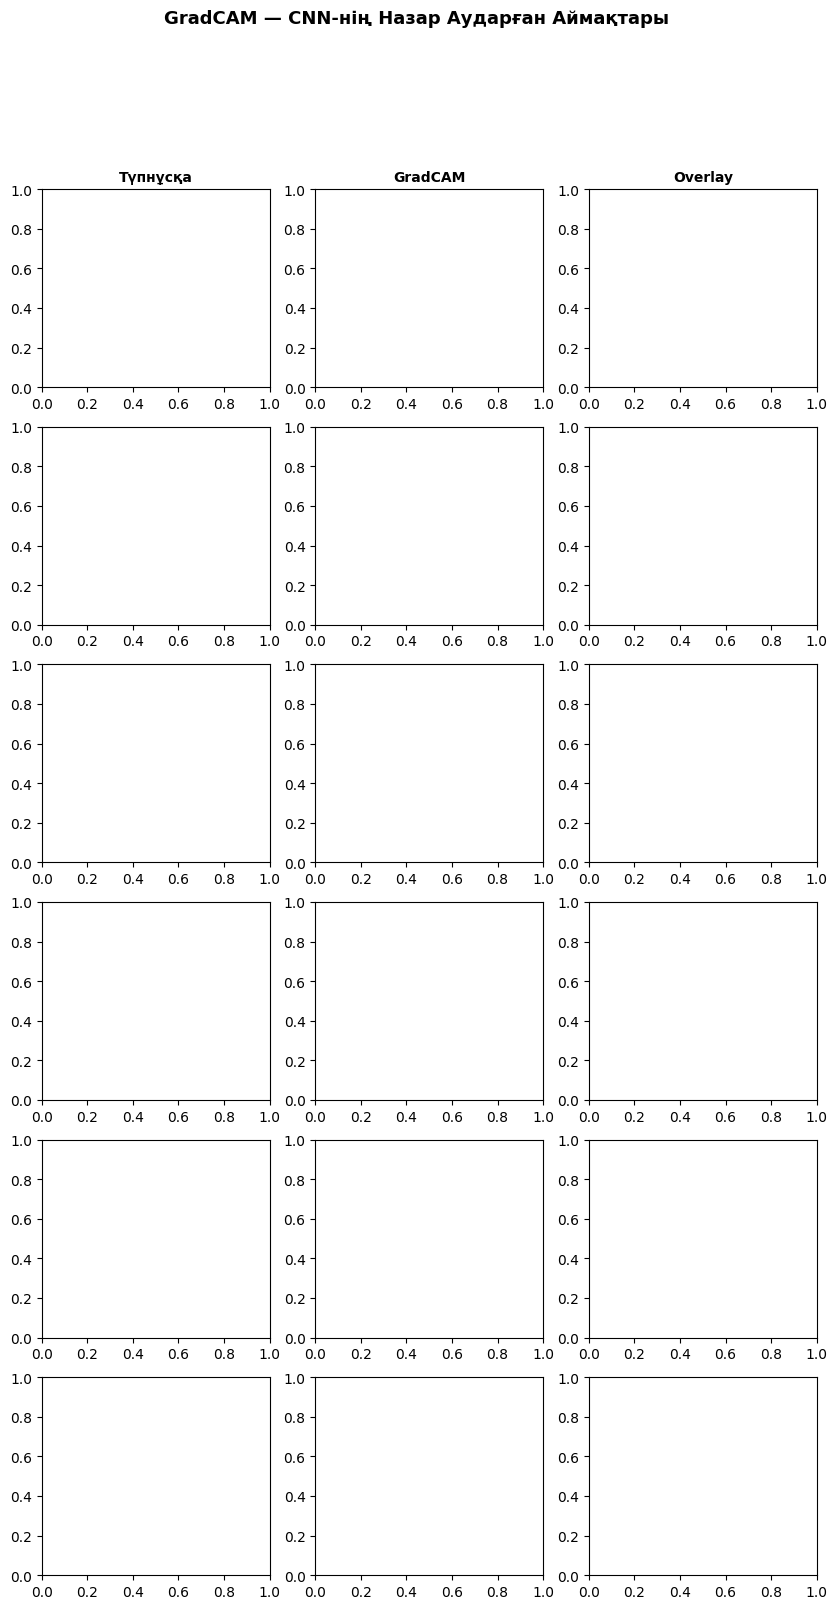

In [13]:
last_conv = [l.name for l in clf_model.layers if isinstance(l, layers.Conv2D)][-1]
print("Соңғы Conv2D қабаты:", last_conv)

sample_gradcam = sample_idx[:6]
fig, axes = plt.subplots(6, 3, figsize=(10, 18))
fig.suptitle('GradCAM — CNN-нің Назар Аударған Аймақтары', fontsize=13, fontweight='bold')

col_titles = ['Түпнұсқа', 'GradCAM', 'Overlay']
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=10, fontweight='bold')

for i, idx in enumerate(sample_gradcam):
    img = x_test_norm[idx:idx+1]
    pred_i = np.argmax(clf_model.predict(img, verbose=0)[0])
    heatmap = compute_gradcam(clf_model, img, last_conv, pred_i)
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], [32, 32]).numpy().squeeze()

    try:
        import cv2 as _cv2
        hm_uint8 = np.uint8(255 * heatmap_resized)
        hm_color = _cv2.applyColorMap(hm_uint8, _cv2.COLORMAP_JET)
        hm_color = _cv2.cvtColor(hm_color, _cv2.COLOR_BGR2RGB) / 255.0
        overlay = 0.6 * x_test[idx] / 255.0 + 0.4 * hm_color
        overlay = np.clip(overlay, 0, 1)
    except ImportError:
        overlay = x_test[idx] / 255.0

    axes[i, 0].imshow(x_test[idx])
    axes[i, 0].axis('off')
    axes[i, 1].imshow(heatmap_resized, cmap='jet')
    axes[i, 1].axis('off')
    axes[i, 2].imshow(overlay)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()


## 5-бөлім: Тапсырма 2 — Объект Детекциясы

Детекция классификациядан күрделірек: сурет ішінде **бірнеше** объектінің **орнын** (bounding box) жəне **типін** анықтайды.

Негізгі метрика — **mAP** (mean Average Precision):
```
IoU = Intersection Area / Union Area
```
Детекция дұрыс деп саналу үшін: IoU ≥ 0.5 (PASCAL VOC) немесе ≥ 0.75 (COCO)

In [15]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - intersection
    return intersection / (union + 1e-10)

print("compute_iou() анықталды.")


compute_iou() анықталды.


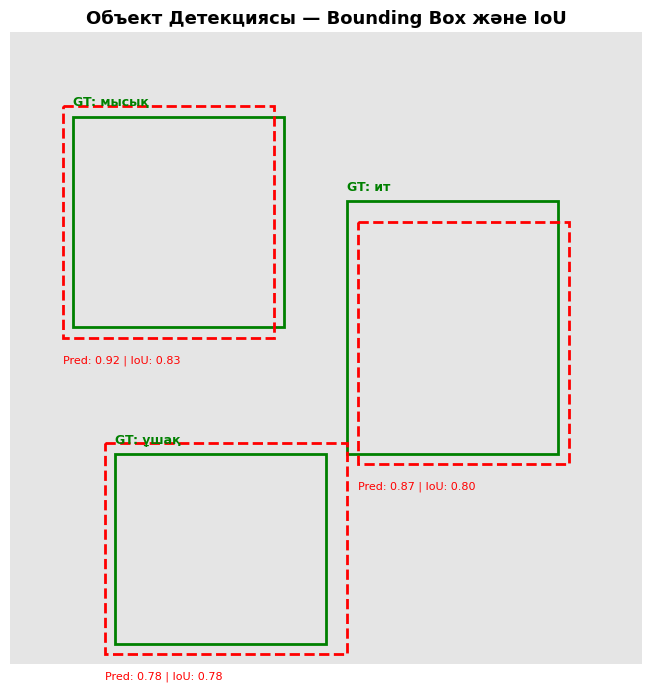

In [16]:
np.random.seed(10)
img_size = 300
demo_img = np.ones((img_size, img_size, 3), dtype=np.float32) * 0.9

gt_boxes = [
    [30, 40, 130, 140, 'мысық'],
    [160, 80, 260, 200, 'ит'],
    [50, 200, 150, 290, 'ұшақ'],
]
pred_boxes = [
    [25, 35, 125, 145, 0.92],
    [165, 90, 265, 205, 0.87],
    [45, 195, 160, 295, 0.78],
]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(demo_img)

for box in gt_boxes:
    x1, y1, x2, y2, label = box
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='green', facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1-5, f'GT: {label}', color='green', fontsize=9, fontweight='bold')

for i, pbox in enumerate(pred_boxes):
    x1, y1, x2, y2, score = pbox
    gt = gt_boxes[i][:4]
    iou = compute_iou([x1, y1, x2, y2], gt)
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
    ax.add_patch(rect)
    ax.text(x1, y2+12, f'Pred: {score:.2f} | IoU: {iou:.2f}', color='red', fontsize=8)

ax.set_xlim(0, img_size)
ax.set_ylim(img_size, 0)
ax.set_title('Объект Детекциясы — Bounding Box жəне IoU', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()


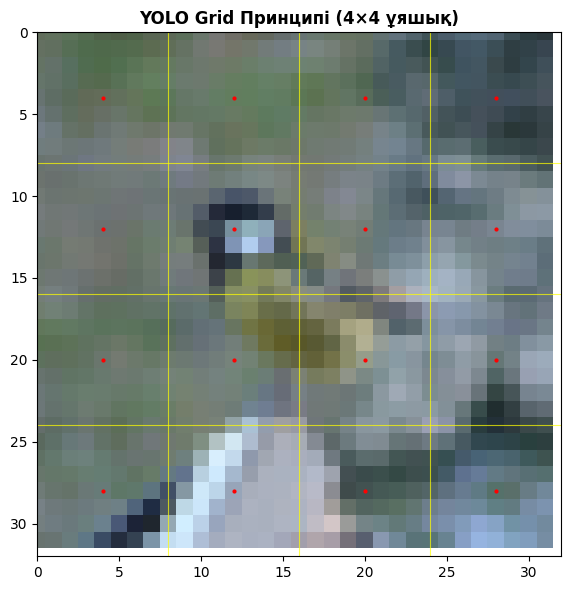

YOLO 4×4 grid: 16 ұяшық, əрқайсысы болжам жасайды.


In [17]:
grid_size = 4
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(x_test[sample_idx[0]])
ax.set_xlim(0, 32)
ax.set_ylim(32, 0)

cell_size = 32 / grid_size
for i in range(1, grid_size):
    ax.axhline(i * cell_size, color='yellow', linewidth=0.8, alpha=0.7)
    ax.axvline(i * cell_size, color='yellow', linewidth=0.8, alpha=0.7)

for row in range(grid_size):
    for col in range(grid_size):
        cx = (col + 0.5) * cell_size
        cy = (row + 0.5) * cell_size
        ax.plot(cx, cy, 'r.', markersize=4)

ax.set_title(f'YOLO Grid Принципі ({grid_size}×{grid_size} ұяшық)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"YOLO {grid_size}×{grid_size} grid: {grid_size**2} ұяшық, əрқайсысы болжам жасайды.")


## 6-бөлім: Тапсырма 3 — Сегментация

Сегментация — əр пиксельге тап береді. Детекциядан айырмасы: bounding box емес, нақты объект пішімі анықталады.

| Тип | Сипаты |
|---|---|
| **Семантикалық** | Əр пиксель → тап (бірдей класс — бір рəң) |
| **Инстанция** | Əр объект — жеке нысан (2 мысық — 2 маска) |
| **Паноптикалық** | Семантикалық + Инстанция біріктірілген |

In [18]:
def build_mini_unet(input_shape=(32, 32, 3), num_classes=1):
    inputs = keras.Input(shape=input_shape)
    e1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    e1 = layers.Conv2D(32, 3, activation='relu', padding='same')(e1)
    p1 = layers.MaxPooling2D(2)(e1)
    e2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    e2 = layers.Conv2D(64, 3, activation='relu', padding='same')(e2)
    p2 = layers.MaxPooling2D(2)(e2)
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(b)
    u2 = layers.UpSampling2D(2)(b)
    u2 = layers.Concatenate()([u2, e2])
    d2 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)
    u1 = layers.UpSampling2D(2)(d2)
    u1 = layers.Concatenate()([u1, e1])
    d1 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(d1)
    return keras.Model(inputs, outputs, name='Mini_UNet')

unet = build_mini_unet()
unet.summary()


Model: "Mini_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     36,928 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 64)  │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 128) │    147,584 │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 16, 16,    │          0 │ conv2d_8[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32, 1) │         33 │ conv2d_10[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 425,377 (1.62 MB)

 Trainable params: 425,377 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

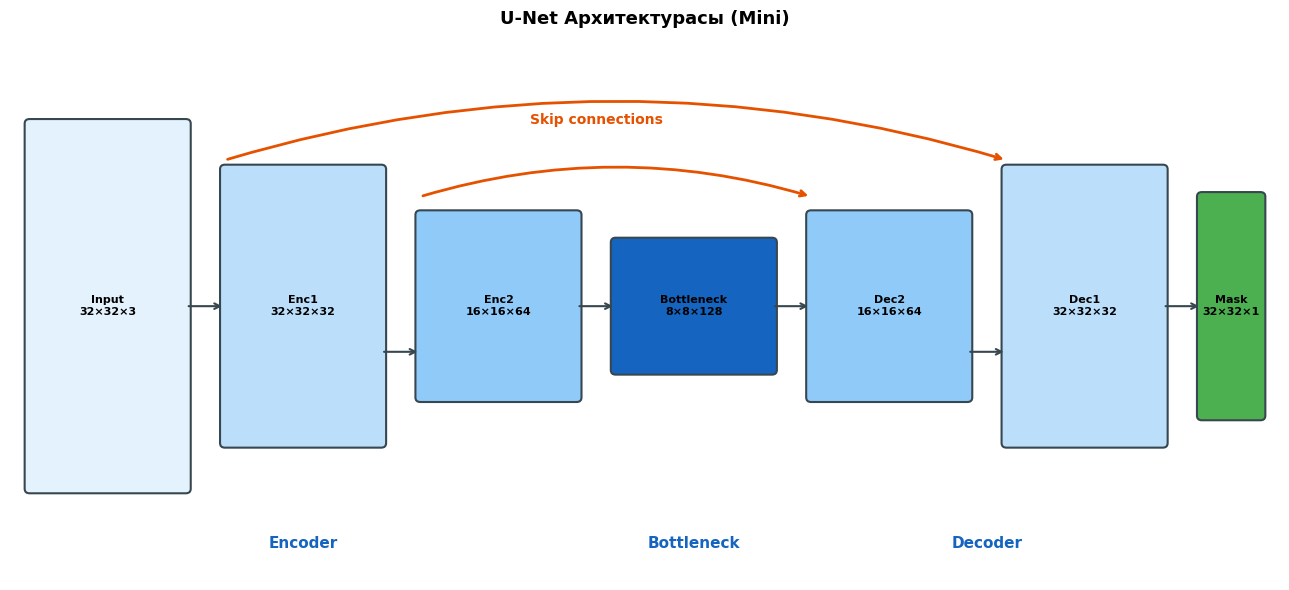

In [19]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('U-Net Архитектурасы (Mini)', fontsize=13, fontweight='bold')

blocks = [
    (0.2, 1.0, 1.6, 4.0, 'Input\n32×32×3', '#e3f2fd'),
    (2.2, 1.5, 1.6, 3.0, 'Enc1\n32×32×32', '#bbdefb'),
    (4.2, 2.0, 1.6, 2.0, 'Enc2\n16×16×64', '#90caf9'),
    (6.2, 2.3, 1.6, 1.4, 'Bottleneck\n8×8×128', '#1565c0'),
    (8.2, 2.0, 1.6, 2.0, 'Dec2\n16×16×64', '#90caf9'),
    (10.2, 1.5, 1.6, 3.0, 'Dec1\n32×32×32', '#bbdefb'),
    (12.2, 1.8, 0.6, 2.4, 'Mask\n32×32×1', '#4caf50'),
]

for x, y, w, h, label, color in blocks:
    rect = patches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.05', facecolor=color, edgecolor='#37474f', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=8, fontweight='bold')

arrow_pairs = [(1.8, 3.0, 2.2, 3.0), (3.8, 2.5, 4.2, 2.5), (5.8, 3.0, 6.2, 3.0), (7.8, 3.0, 8.2, 3.0), (9.8, 2.5, 10.2, 2.5), (11.8, 3.0, 12.2, 3.0)]
for x1, y1, x2, y2 in arrow_pairs:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='->', color='#37474f', lw=1.5))

ax.annotate('', xy=(10.2, 4.6), xytext=(2.2, 4.6), arrowprops=dict(arrowstyle='->', color='#e65100', lw=2, connectionstyle='arc3,rad=-0.15'))
ax.annotate('', xy=(8.2, 4.2), xytext=(4.2, 4.2), arrowprops=dict(arrowstyle='->', color='#e65100', lw=2, connectionstyle='arc3,rad=-0.15'))
ax.text(6.0, 5.0, 'Skip connections', ha='center', color='#e65100', fontsize=10, fontweight='bold')
ax.text(3.0, 0.35, 'Encoder', ha='center', fontsize=11, color='#1565c0', fontweight='bold')
ax.text(7.0, 0.35, 'Bottleneck', ha='center', fontsize=11, color='#1565c0', fontweight='bold')
ax.text(10.0, 0.35, 'Decoder', ha='center', fontsize=11, color='#1565c0', fontweight='bold')

plt.tight_layout()
plt.show()


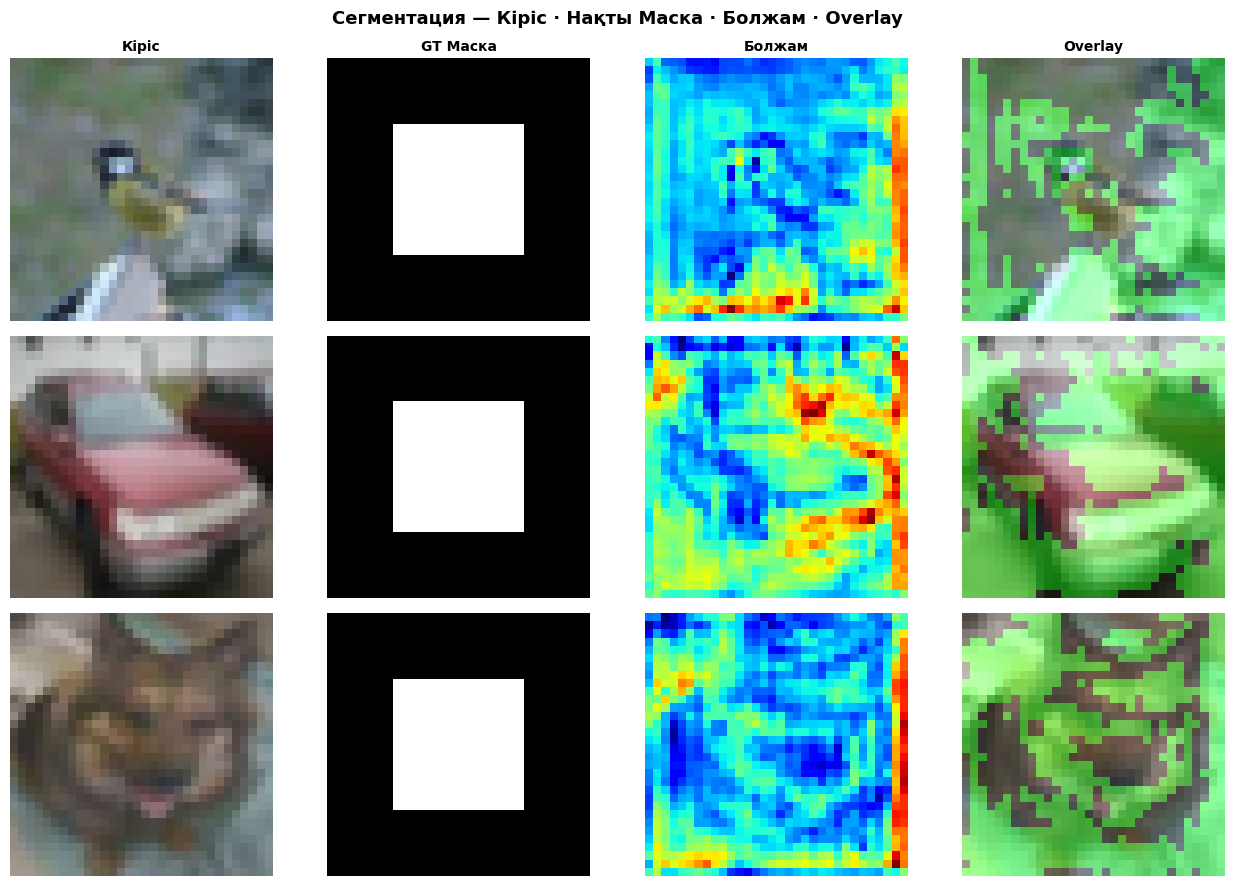

In [20]:
np.random.seed(77)

fig, axes = plt.subplots(3, 4, figsize=(13, 9))
fig.suptitle('Сегментация — Кіріс · Нақты Маска · Болжам · Overlay', fontsize=13, fontweight='bold')

for row in range(3):
    idx = sample_idx[row]
    img = x_test[idx]
    gt_mask = np.zeros((32, 32), dtype=np.float32)
    gt_mask[8:24, 8:24] = 1.0
    pred_mask = unet.predict(x_test_norm[idx:idx+1], verbose=0)[0, :, :, 0]
    pred_binary = (pred_mask > 0.5).astype(np.float32)
    overlay = img.copy().astype(np.float32) / 255.0
    overlay[..., 1] = np.clip(overlay[..., 1] + 0.4 * pred_binary, 0, 1)
    axes[row, 0].imshow(img)
    axes[row, 0].set_ylabel(CLASS_NAMES[y_test_flat[idx]], fontsize=9, fontweight='bold')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(gt_mask, cmap='gray')
    axes[row, 1].axis('off')
    axes[row, 2].imshow(pred_mask, cmap='jet')
    axes[row, 2].axis('off')
    axes[row, 3].imshow(overlay)
    axes[row, 3].axis('off')

col_titles = ['Кіріс', 'GT Маска', 'Болжам', 'Overlay']
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


## 7-бөлім: Тапсырма 4 — Кескін Генерациясы

Кескін генерациясы — жаңа, нақты суреттерге ұқсас синтетикалық кескіндер жасайды:

| Əдіс | Принцип |
|---|---|
| **GAN** | Generator vs Discriminator |
| **VAE** | Latent кеңістіктен сэмплдеу |
| **Diffusion** | Шудан кері барып сурет жасау |
| **Style Transfer** | Контент + стиль суреттерін біріктіру |

In [21]:
LATENT_DIM = 128

def build_generator(latent_dim):
    return keras.Sequential([
        layers.Dense(8 * 8 * 128, input_shape=(latent_dim,)),
        layers.Reshape((8, 8, 128)),
        layers.Conv2DTranspose(64, 4, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2DTranspose(32, 4, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(3, 3, padding='same', activation='tanh'),
    ], name='DCGAN_Generator')

def build_discriminator():
    return keras.Sequential([
        layers.Conv2D(32, 4, strides=2, padding='same', input_shape=(32,32,3)),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Conv2D(64, 4, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid'),
    ], name='DCGAN_Discriminator')

generator = build_generator(LATENT_DIM)
discriminator = build_discriminator()

print("Generator:")
generator.summary()
print("\nDiscriminator:")
discriminator.summary()


Generator:


Model: "DCGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 8192)           │     1,056,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 32)     │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,221,955 (4.66 MB)

 Trainable params: 1,221,763 (4.66 MB)

...

Model: "DCGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,497 (150.38 KB)

 Trainable params: 38,497 (150.38 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
x_gan = (x_train.astype('float32') - 127.5) / 127.5

class DCGAN(keras.Model):
    def __init__(self, generator, discriminator, latent_dim):
        super().__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim
        self.d_loss_tracker = keras.metrics.Mean(name='d_loss')
        self.g_loss_tracker = keras.metrics.Mean(name='g_loss')

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        noise = tf.random.normal([batch_size, self.latent_dim])
        fake_images = self.generator(noise, training=False)
        combined = tf.concat([real_images, fake_images], axis=0)
        labels = tf.concat([tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))], axis=0)
        labels += 0.05 * tf.random.uniform(tf.shape(labels))

        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined, training=True)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        noise = tf.random.normal([batch_size, self.latent_dim])
        misleading_labels = tf.ones((batch_size, 1))

        with tf.GradientTape() as tape:
            generated_images = self.generator(noise, training=True)
            predictions = self.discriminator(generated_images, training=False)
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)
        return {'d_loss': self.d_loss_tracker.result(), 'g_loss': self.g_loss_tracker.result()}

dcgan = DCGAN(generator, discriminator, LATENT_DIM)
dcgan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss_fn=keras.losses.BinaryCrossentropy()
)
print("DCGAN моделі дайын.")


DCGAN моделі дайын.


In [23]:
print("DCGAN үйретілуде (20 дəуір)...")
history_gan = dcgan.fit(
    x_gan,
    epochs=20,
    batch_size=128,
    verbose=1
)
print("Аяқталды.")

DCGAN үйретілуде (20 дəуір)...
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - d_loss: -71.4014 - g_loss: 0.0343
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - d_loss: 2005.2615 - g_loss: 0.1088
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - d_loss: 1148.5706 - g_loss: 0.0231
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - d_loss: 516.3925 - g_loss: 0.2200
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - d_loss: 193.3412 - g_loss: 0.1591
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - d_loss: 85.1686 - g_loss: 0.1372 
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - d_loss: 23.2395 - g_loss: 0.0487
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - d_loss: 18.5558 - g_loss: 0.1584
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - d_loss: 12.5104 - g_loss: 0.4767
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - d_loss: 9.2880 - g_loss: 1.6129 
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - d_loss: 4.7658 - g_loss

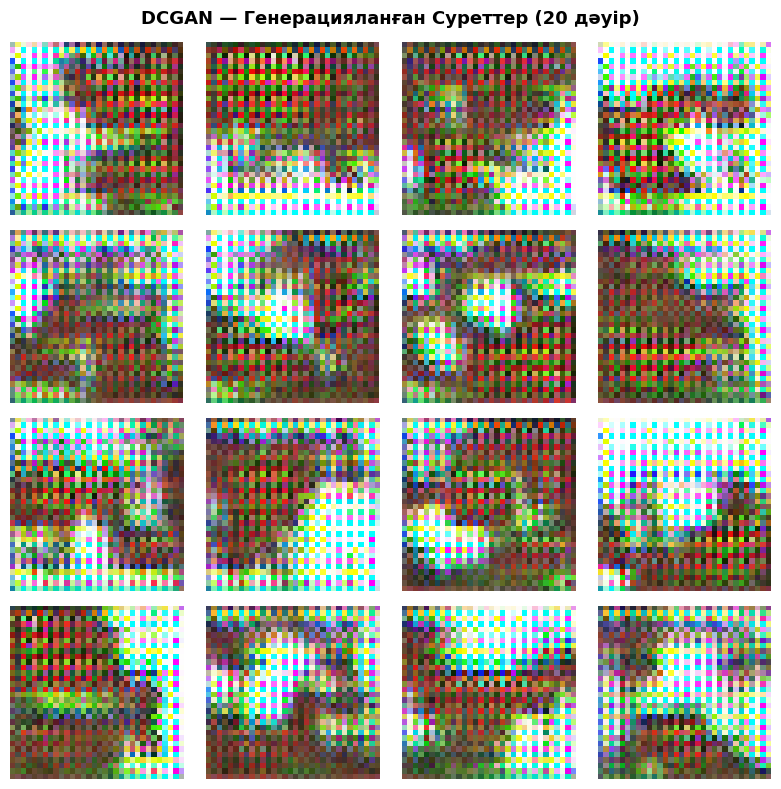

In [24]:
noise_final = tf.random.normal([16, LATENT_DIM])
gen_imgs = generator(noise_final, training=False).numpy()
gen_imgs = ((gen_imgs + 1) / 2.0 * 255).astype(np.uint8)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle(f'DCGAN — Генерацияланған Суреттер (20 дəуір)', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(gen_imgs[i])
    ax.axis('off')

plt.tight_layout()
plt.show()


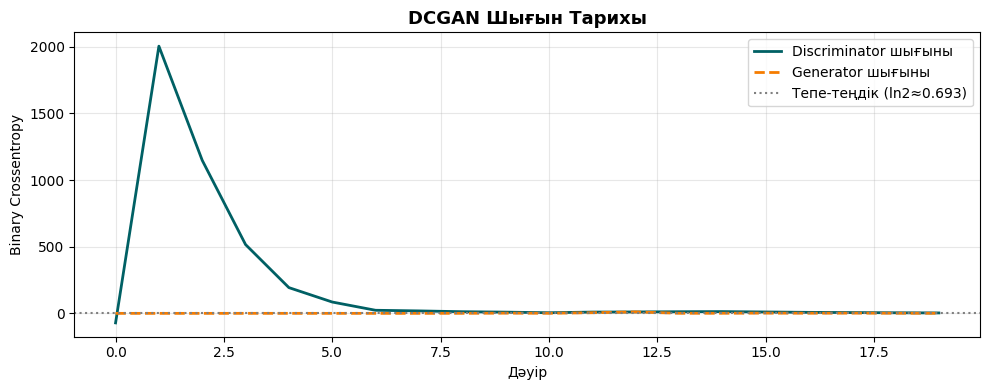

In [25]:
d_losses = history_gan.history['d_loss']
g_losses = history_gan.history['g_loss']

plt.figure(figsize=(10, 4))
plt.plot(d_losses, label='Discriminator шығыны', linewidth=2, color='#006064')
plt.plot(g_losses, label='Generator шығыны', linewidth=2, color='#f57c00', linestyle='--')
plt.axhline(y=0.693, color='gray', linestyle=':', linewidth=1.5, label='Тепе-теңдік (ln2≈0.693)')
plt.title('DCGAN Шығын Тарихы', fontsize=13, fontweight='bold')
plt.xlabel('Дəуір')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8-бөлім: CV Тапсырмалары Метрикалары

Əр тапсырманың өзіне тəн бағалау метрикасы бар:

In [26]:
import pandas as pd

metrics_df = pd.DataFrame([
    {'Тапсырма': 'Классификация', 'Метрика': 'Top-1 Accuracy', 'Формула': 'Дұрыс / Жалпы', 'Жоғары=Жақсы': True, 'Модельдер': 'ResNet, VGG, EfficientNet'},
    {'Тапсырма': 'Детекция', 'Метрика': 'mAP (mean AP)', 'Формула': 'Орт. Avg Precision (IoU≥0.5)', 'Жоғары=Жақсы': True, 'Модельдер': 'YOLO, Faster R-CNN, SSD'},
    {'Тапсырма': 'Сегментация', 'Метрика': 'mIoU / Dice', 'Формула': 'Mean IoU немесе 2·TP/(2TP+FP+FN)', 'Жоғары=Жақсы': True, 'Модельдер': 'U-Net, DeepLab, Mask R-CNN'},
    {'Тапсырма': 'Генерация', 'Метрика': 'FID (Frechet Inception Distance)', 'Формула': 'Нақты мен жалған үлестірімінің айырмасы', 'Жоғары=Жақсы': False, 'Модельдер': 'DCGAN, StyleGAN, Diffusion'},
])

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(metrics_df.to_string(index=False))


     Тапсырма                          Метрика                                 Формула  Жоғары=Жақсы                  Модельдер
Классификация                   Top-1 Accuracy                           Дұрыс / Жалпы          True  ResNet, VGG, EfficientNet
     Детекция                    mAP (mean AP)            Орт. Avg Precision (IoU≥0.5)          True    YOLO, Faster R-CNN, SSD
  Сегментация                      mIoU / Dice        Mean IoU немесе 2·TP/(2TP+FP+FN)          True U-Net, DeepLab, Mask R-CNN
    Генерация FID (Frechet Inception Distance) Нақты мен жалған үлестірімінің айырмасы         False DCGAN, StyleGAN, Diffusion


## 9-бөлім: Рефлексиялық Сұрақтар

**Сұрақ 1.** Классификация мен детекцияның архитектуралық айырмасы неде? Детекция неліктен күрделірек?

Классификация бір суретке бір ғана класс береді, сондықтан оның соңында көбіне softmax қабаты болады. Детекция суреттегі объектінің класын да, координатасын да табады, сондықтан модельге bounding box регрессиясы, confidence score, IoU, anchor немесе grid логикасы қажет. Бір суретте бірнеше объект болуы мүмкін болғандықтан, детекция күрделірек.

**Сұрақ 2.** GradCAM суреттің ненде екенін анықтауда дəл болып шықты ма? Кей жағдайларда неге нақты болмауы мүмкін?

GradCAM модель шешім қабылдағанда қай аймақтарға көбірек сүйенгенін көрсетеді. Ол әрдайым объектінің толық пішінін дәл бермейді, себебі соңғы convolution қабатының өлшемі кішірейген және модель кейде объектінің бір ғана маңызды бөлігіне немесе фондағы корреляцияға сүйенуі мүмкін.

**Сұрақ 3.** U-Net-тегі Skip connection-дар не үшін маңызды? Оларды алып тастасақ не болар еді?

Skip connection encoder-дегі жоғары ажыратымдылықтағы кеңістіктік ақпаратты decoder-ге жеткізеді. Олар болмаса, decoder тек bottleneck-тегі қысылған ақпаратпен жұмыс істейді, сондықтан маска шекаралары бұлыңғыр болып, ұсақ детальдар жоғалады.

**Сұрақ 4.** IoU ≥ 0.5 шегі PASCAL VOC-та, ≥ 0.75 COCO-да қолданылады. Қатаңырақ шек (0.75) нені білдіреді?

0.75 шегі болжанған box нақты box-пен әлдеқайда көбірек қабысуы керек дегенді білдіреді. Яғни модель объектіні шамамен тапқаны жеткіліксіз, оның орнын да дәл белгілеуі қажет.

**Сұрақ 5.** FID скоры неліктен pixel-level MSE орнына қолданылады? FID-тің артықшылығы неде?

Pixel-level MSE суреттерді пиксель бойынша салыстырады, сондықтан визуалды сапа мен табиғилықты жақсы өлшемейді. FID нақты және генерацияланған суреттердің feature кеңістігіндегі үлестірімдерін салыстырады, сондықтан ол генерацияның реалистігін және әртүрлілігін жақсырақ бағалайды.


## Қорытынды

Осы шолу дəптерінде CNN классификаторын CIFAR-10 деректерінде үйрету, GradCAM арқылы модель назарын визуализациялау, IoU формуласымен bounding box детекциясын бағалау, Mini U-Net архитектурасын құру және DCGAN арқылы синтетикалық кескін генерациялау орындалды.

<div style="background-color:#e0f7fa; border-left:5px solid #006064; padding:12px 16px; border-radius:6px; margin-top:16px;">
  <strong>Нəтиже:</strong> дəптер Computer Vision-дің негізгі тапсырмаларын бір толық, іске қосылатын workflow ретінде көрсетеді.
</div>
